In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [4]:
df=pd.read_csv(r'data/KC_Data.csv')
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,floors,waterfront,view,condition,...,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,sqft_lot,sqft_above,sqft_basement
0,7129300520,20141013T000000,221900.0,3,1.00,1180,1.0,0,0,3,...,1955,0,98178,47.5112,-122.257,1340,5650,5650,1180,0
1,6414100192,20141209T000000,538000.0,3,2.25,2570,2.0,0,0,3,...,1951,1991,98125,47.7210,-122.319,1690,7639,7242,2170,400
2,5631500400,20150225T000000,180000.0,2,1.00,770,1.0,0,0,3,...,1933,0,98028,47.7379,-122.233,2720,8062,10000,770,0
3,2487200875,20141209T000000,604000.0,4,3.00,1960,1.0,0,0,5,...,1965,0,98136,47.5208,-122.393,1360,5000,5000,1050,910
4,1954400510,20150218T000000,510000.0,3,2.00,1680,1.0,0,0,3,...,1987,0,98074,47.6168,-122.045,1800,7503,8080,1680,0


In [5]:
df.columns

Index(['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'yr_built', 'yr_renovated',
       'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15', 'sqft_lot',
       'sqft_above', 'sqft_basement'],
      dtype='object')

- grade --> construction and architectural design. Was the house well-designed? Are materials high-end? Is it aesthetically impressive?

- Condition --> Describes the overall current state or wear-and-tear of the house. Is the house well-maintained? Does it need repairs?

- sqft_living-->	Interior living area of the house (square feet).
- sqft_lot-->	    Total land (lot) area of the property (square feet).
- sqft_above-->	    Living area above ground level (does not include basement).
- sqft_basement-->	Basement area (square feet).
- sqft_living15-->	Average living area of the 15 nearest neighboring houses.
- sqft_lot15-->	    Average lot size of the 15 nearest neighboring properties.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   floors         21613 non-null  float64
 7   waterfront     21613 non-null  int64  
 8   view           21613 non-null  int64  
 9   condition      21613 non-null  int64  
 10  grade          21613 non-null  int64  
 11  yr_built       21613 non-null  int64  
 12  yr_renovated   21613 non-null  int64  
 13  zipcode        21613 non-null  int64  
 14  lat            21613 non-null  float64
 15  long           21613 non-null  float64
 16  sqft_living15  21613 non-null  int64  
 17  sqft_lot15     21613 non-null  int64  
 18  sqft_l

### Fix Date Column

In [7]:
df['date'] = pd.to_datetime(df['date'], format='%Y%m%dT%H%M%S')

### EDA

In [8]:
df.isnull().sum()

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
floors           0
waterfront       0
view             0
condition        0
grade            0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
sqft_lot         0
sqft_above       0
sqft_basement    0
dtype: int64

In [9]:
df.duplicated(subset='id').sum()

177

In [10]:
df[df.duplicated(subset='id',keep=False)].sort_values(by='id',ascending=True).head()

,id,date,price,bedrooms,bathrooms,sqft_living,floors,waterfront,view,condition,...,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,sqft_lot,sqft_above,sqft_basement
2497,1000102,2015-04-22,300000.0,6,3.00,2400,2.0,0,0,3,...,1991,0,98002,47.3262,-122.214,2060,7316,9373,2400,0
2496,1000102,2014-09-16,280000.0,6,3.00,2400,2.0,0,0,3,...,1991,0,98002,47.3262,-122.214,2060,7316,9373,2400,0
16814,7200179,2014-10-16,150000.0,2,1.00,840,1.0,0,0,3,...,1925,0,98055,47.4840,-122.211,1480,6969,12750,840,0
16815,7200179,2015-04-24,175000.0,2,1.00,840,1.0,0,0,3,...,1925,0,98055,47.4840,-122.211,1480,6969,12750,840,0
11434,109200390,2014-10-20,250000.0,3,1.75,1480,1.0,0,0,4,...,1980,0,98023,47.2977,-122.367,1830,6956,3900,1480,0


Here we can see that the same house may be sold multiple times

In [11]:
df.shape

(21613, 21)

In [12]:
df.duplicated().sum()

0

In [13]:
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,floors,waterfront,view,condition,...,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,sqft_lot,sqft_above,sqft_basement
0,7129300520,2014-10-13,221900.0,3,1.00,1180,1.0,0,0,3,...,1955,0,98178,47.5112,-122.257,1340,5650,5650,1180,0
1,6414100192,2014-12-09,538000.0,3,2.25,2570,2.0,0,0,3,...,1951,1991,98125,47.7210,-122.319,1690,7639,7242,2170,400
2,5631500400,2015-02-25,180000.0,2,1.00,770,1.0,0,0,3,...,1933,0,98028,47.7379,-122.233,2720,8062,10000,770,0
3,2487200875,2014-12-09,604000.0,4,3.00,1960,1.0,0,0,5,...,1965,0,98136,47.5208,-122.393,1360,5000,5000,1050,910
4,1954400510,2015-02-18,510000.0,3,2.00,1680,1.0,0,0,3,...,1987,0,98074,47.6168,-122.045,1800,7503,8080,1680,0


In [14]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
id,21613.0,4580301520.864988,1000102.0,2123049194.0,3904930410.0,7308900445.0,9900000190.0,2876565571.312049
date,21613,2014-10-29 04:38:01.959931648,2014-05-02 00:00:00,2014-07-22 00:00:00,2014-10-16 00:00:00,2015-02-17 00:00:00,2015-05-27 00:00:00,NaN
price,21613.0,540182.158793,75000.0,321950.0,450000.0,645000.0,7700000.0,367362.231718
bedrooms,21613.0,3.370842,0.0,3.0,3.0,4.0,33.0,0.930062
bathrooms,21613.0,2.114757,0.0,1.75,2.25,2.5,8.0,0.770163
sqft_living,21613.0,2079.899736,290.0,1427.0,1910.0,2550.0,13540.0,918.440897
floors,21613.0,1.494309,1.0,1.0,1.5,2.0,3.5,0.539989
waterfront,21613.0,0.007542,0.0,0.0,0.0,0.0,1.0,0.086517
view,21613.0,0.234303,0.0,0.0,0.0,0.0,4.0,0.766318
condition,21613.0,3.40943,1.0,3.0,3.0,4.0,5.0,0.650743


We have in some columns an outliers

In [15]:
df_grouped_date_price=df.groupby('date')['price'].mean()

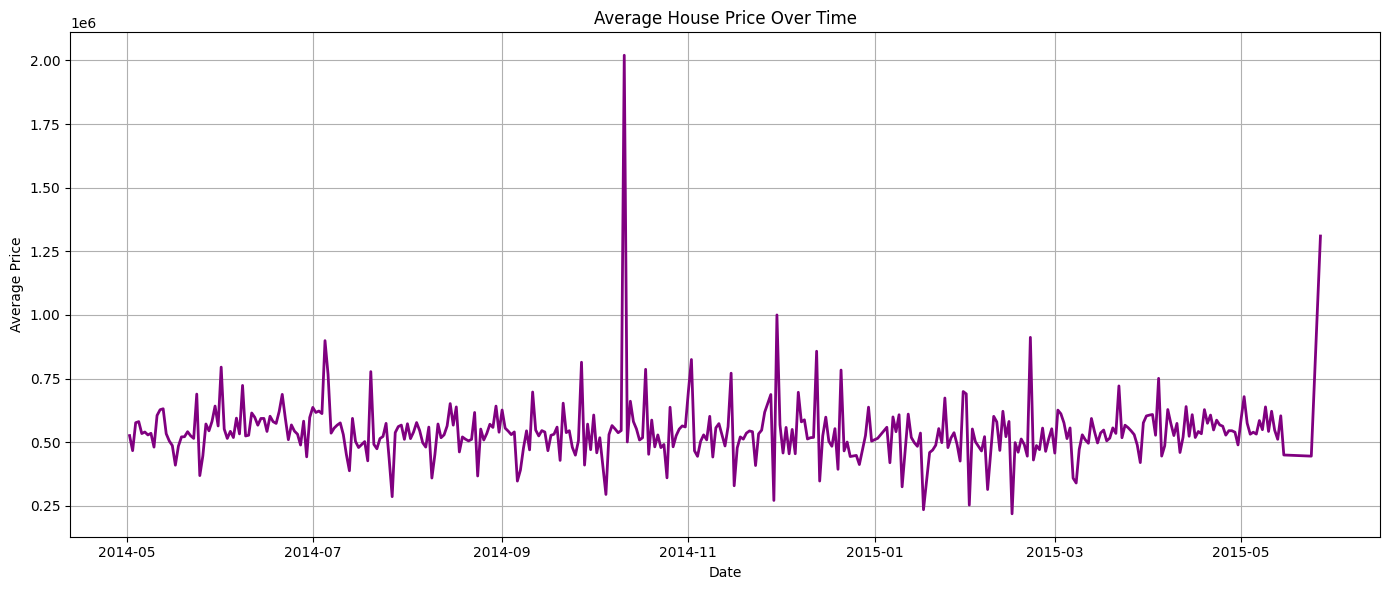

In [16]:
# Plot the average price over time
plt.figure(figsize=(14, 6))
plt.plot(df_grouped_date_price, color='purple', linewidth=2)
plt.title('Average House Price Over Time')
plt.xlabel('Date')
plt.ylabel('Average Price')
plt.grid(True)
plt.tight_layout()
plt.show()

There is dates that the prices are very high and selling is trend in them

In [17]:
df['effective_year']=df[['yr_built', 'yr_renovated']].max(axis=1)

Created a new feature 'effective_year' by taking the maximum of 'yr_built' and 'yr_renovated'. This represents the most recent year the house was either built or renovated, providing a better indicator of the property's effective age and condition.

In [18]:
df['age_when_sold']=df['date'].dt.year-df['effective_year']

In [19]:
df[['age_when_sold','yr_built','yr_renovated','effective_year','date']].head()

,age_when_sold,yr_built,yr_renovated,effective_year,date
0,59,1955,0,1955,2014-10-13
1,23,1951,1991,1991,2014-12-09
2,82,1933,0,1933,2015-02-25
3,49,1965,0,1965,2014-12-09
4,28,1987,0,1987,2015-02-18


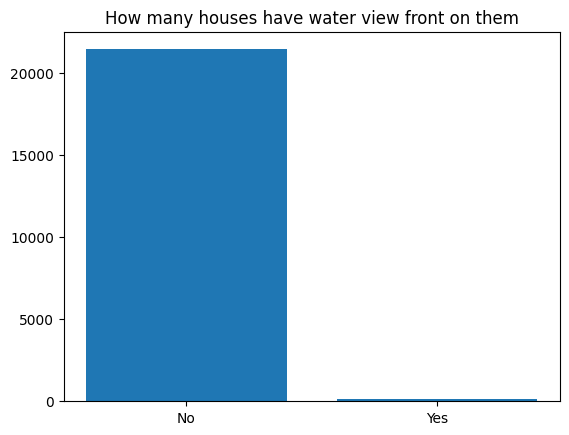

In [20]:
cnt_wtr=df['waterfront'].value_counts()
plt.title('How many houses have water view front on them')
plt.bar(x=cnt_wtr.index,height=cnt_wtr.values)
plt.xticks([0,1],['No','Yes'])
plt.show()

<Axes: xlabel='waterfront', ylabel='price'>

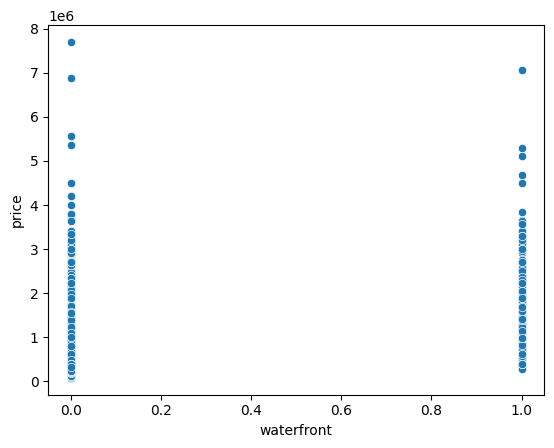

In [21]:
sns.scatterplot(x='waterfront',y='price',data=df)

This indicates that having a waterfront property does not necessarily guarantee a higher selling price.

In [22]:
df_grouped_zipcode_price=df.groupby('zipcode')['price'].mean()

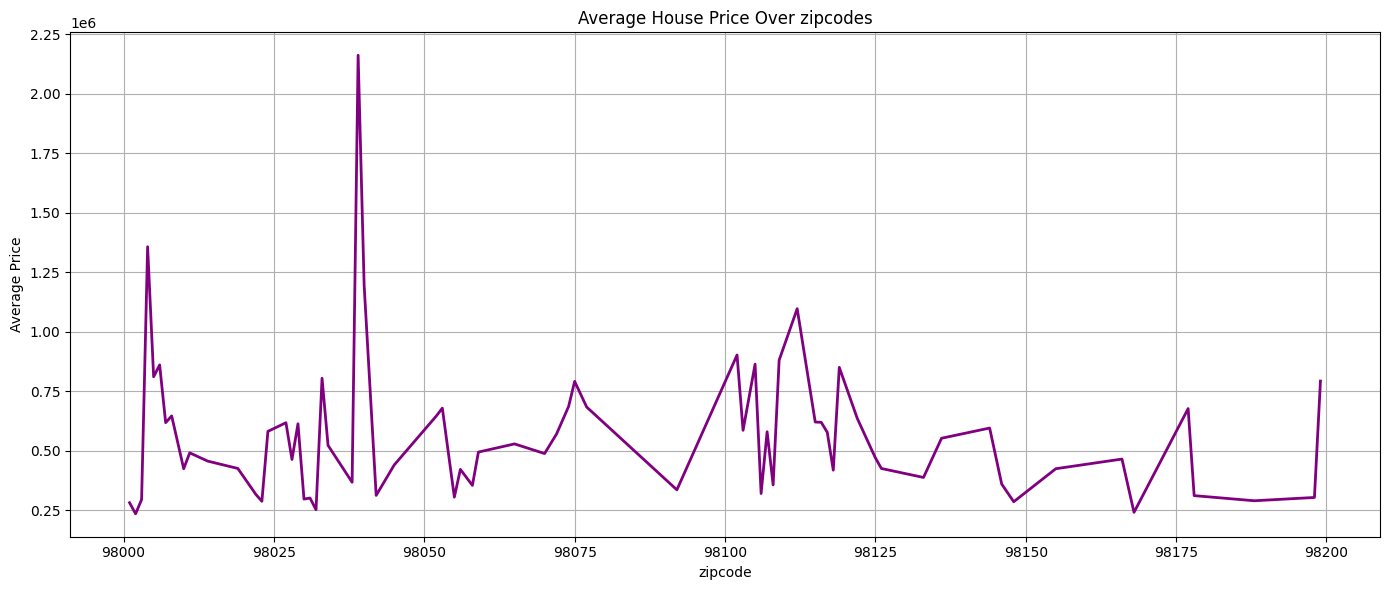

In [23]:
# Plot the average price over time
plt.figure(figsize=(14, 6))
plt.plot(df_grouped_zipcode_price, color='purple', linewidth=2)
plt.title('Average House Price Over zipcodes')
plt.xlabel('zipcode')
plt.ylabel('Average Price')
plt.grid(True)
plt.tight_layout()
plt.show()

There is some areas that the prices are very high in it

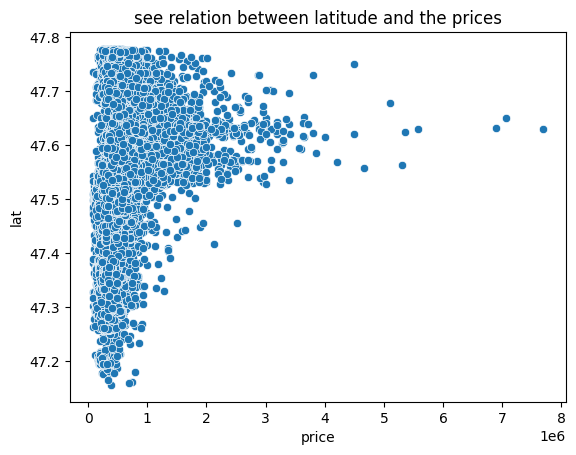

In [24]:
plt.title('see relation between latitude and the prices')
sns.scatterplot(y='lat',x='price',data=df)
plt.show()

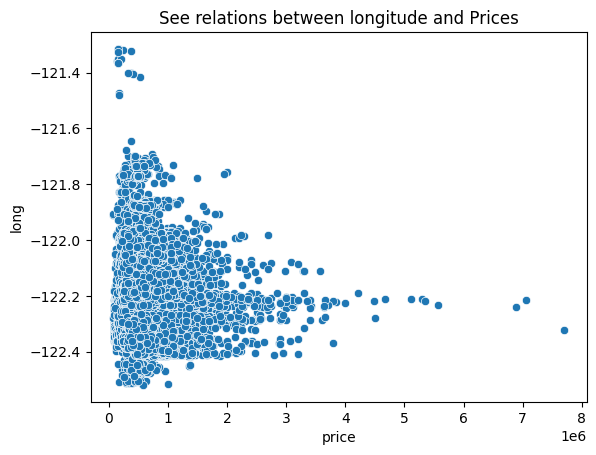

In [25]:
plt.title('See relations between longitude and Prices')
sns.scatterplot(y='long',x='price',data=df)
plt.show()

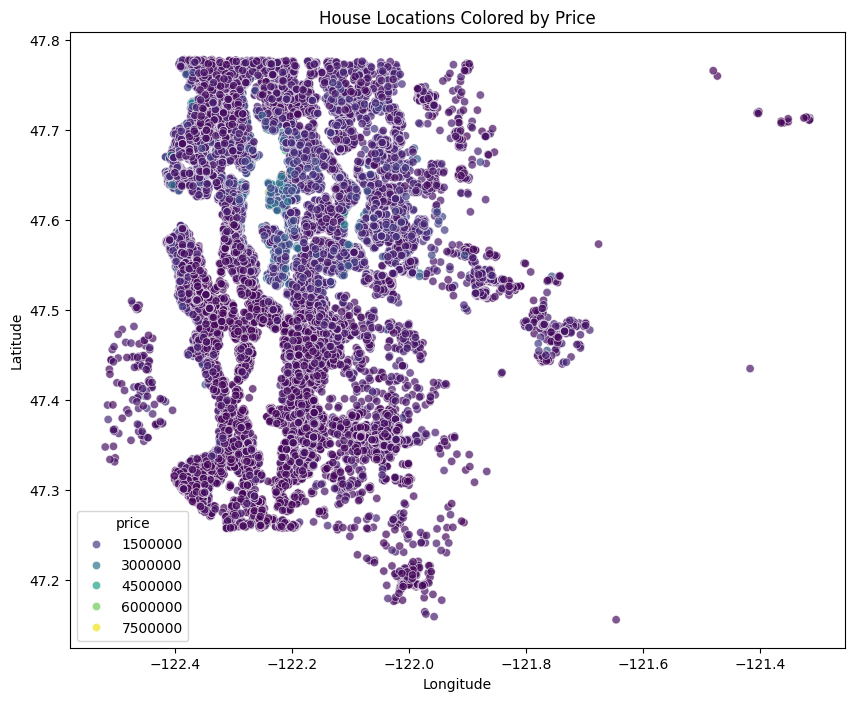

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))

sns.scatterplot(
    data=df,
    x='long',
    y='lat',
    hue='price',        # Color represents price
    palette='viridis',
    alpha=0.7
)

plt.title('House Locations Colored by Price')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

- Houses are clustered in populated neighborhoods.
- Most of our dataset are at low end prices

In [27]:
df['lat_long'] = df['lat'] * df['long']

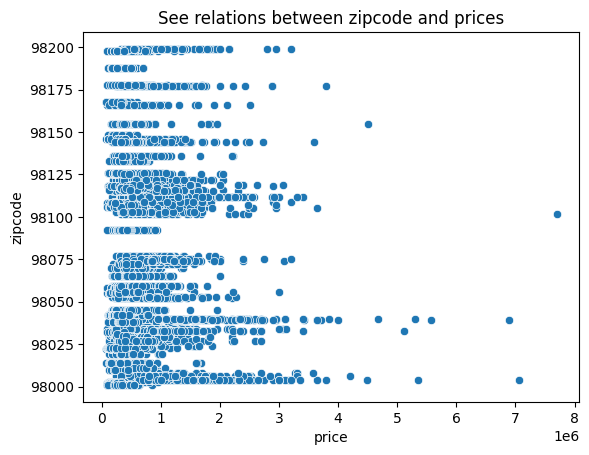

In [28]:
plt.title('See relations between zipcode and prices')
sns.scatterplot(y='zipcode',x='price',data=df)
plt.show()

In [29]:
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,floors,waterfront,view,condition,...,lat,long,sqft_living15,sqft_lot15,sqft_lot,sqft_above,sqft_basement,effective_year,age_when_sold,lat_long
0,7129300520,2014-10-13,221900.0,3,1.00,1180,1.0,0,0,3,...,47.5112,-122.257,1340,5650,5650,1180,0,1955,59,-5808.576778
1,6414100192,2014-12-09,538000.0,3,2.25,2570,2.0,0,0,3,...,47.7210,-122.319,1690,7639,7242,2170,400,1991,23,-5837.184999
2,5631500400,2015-02-25,180000.0,2,1.00,770,1.0,0,0,3,...,47.7379,-122.233,2720,8062,10000,770,0,1933,82,-5835.146731
3,2487200875,2014-12-09,604000.0,4,3.00,1960,1.0,0,0,5,...,47.5208,-122.393,1360,5000,5000,1050,910,1965,49,-5816.213274
4,1954400510,2015-02-18,510000.0,3,2.00,1680,1.0,0,0,3,...,47.6168,-122.045,1800,7503,8080,1680,0,1987,28,-5811.392356


In [30]:
df['zipcode'].value_counts()

zipcode
98103    602
98038    590
98115    583
98052    574
98117    553
        ... 
98102    105
98010    100
98024     81
98148     57
98039     50
Name: count, Length: 70, dtype: int64

In [31]:
# df.drop(columns='region',axis=1,inplace=True)

In [32]:
import pandas as pd
import numpy as np
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Compute zipcode centroids
zip_centers = (
    df.groupby('zipcode')[['lat', 'long']]
      .mean()
)

# Scale coordinates
scaler = StandardScaler()
X = scaler.fit_transform(zip_centers)

In [33]:
results = []

best_score = -1
best_k = None

for k in range(2, 16):

    model = AgglomerativeClustering(
        n_clusters=k,
        linkage='ward'
    )

    labels = model.fit_predict(X)

    score = silhouette_score(X, labels)

    results.append({
        'n_clusters': k,
        'silhouette': score
    })

    if score > best_score:
        best_score = score
        best_k = k

results_df = pd.DataFrame(results)

print(results_df)

print(f"\nBest Number of Clusters: {best_k}")
print(f"Best Silhouette Score: {best_score:.3f}")

    n_clusters  silhouette
0            2    0.356101
1            3    0.386914
2            4    0.323584
3            5    0.344521
4            6    0.345941
5            7    0.345765
6            8    0.342608
7            9    0.350947
8           10    0.364453
9           11    0.370520
10          12    0.350116
11          13    0.333157
12          14    0.336012
13          15    0.338673

Best Number of Clusters: 3
Best Silhouette Score: 0.387


### See best K we can use in practice

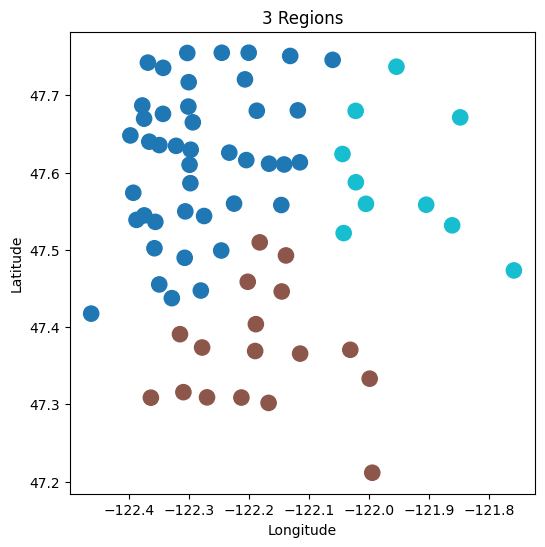

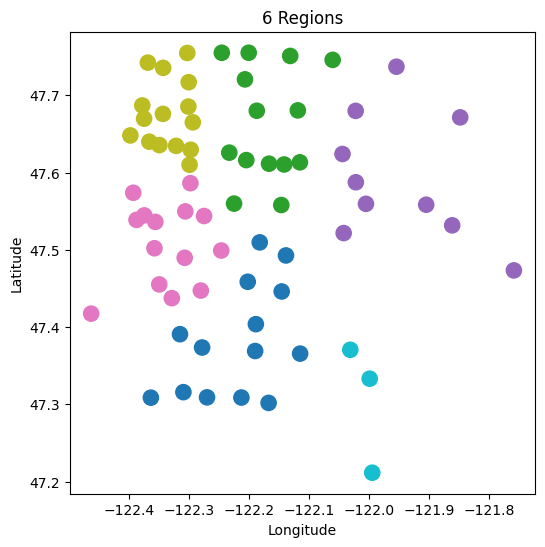

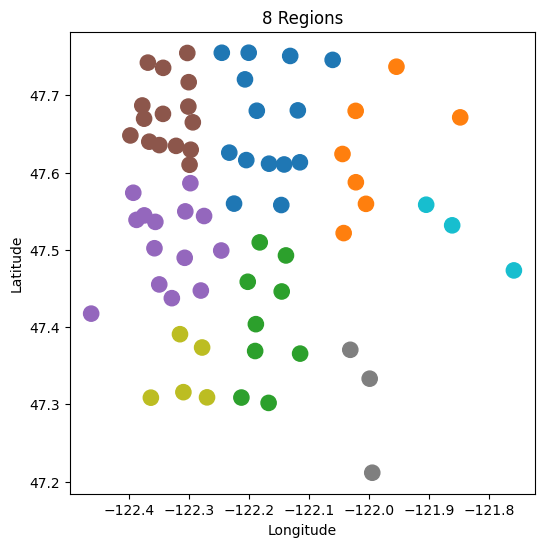

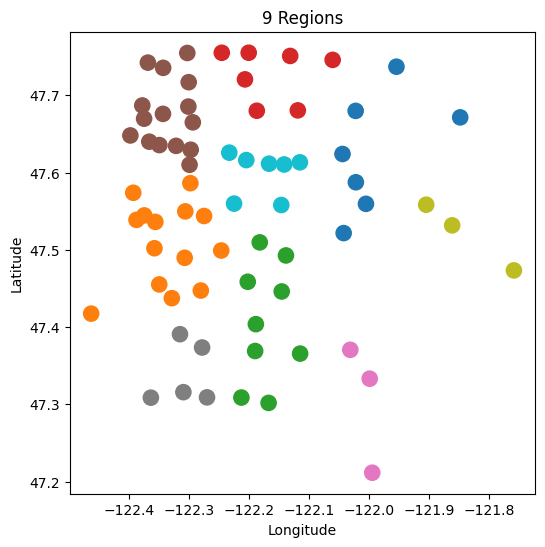

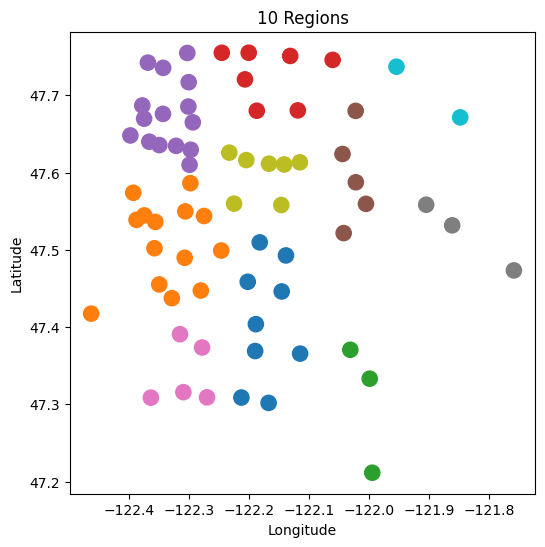

In [34]:
for k in [3, 6, 8, 9, 10]:
    model = AgglomerativeClustering(
        n_clusters=k,
        linkage='ward'
    )

    labels = model.fit_predict(X)

    plt.figure(figsize=(6,6))
    plt.scatter(
        zip_centers['long'],
        zip_centers['lat'],
        c=labels,
        cmap='tab10',
        s=120
    )

    plt.title(f'{k} Regions')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.show()

In [35]:
model = AgglomerativeClustering(
    n_clusters=9,
    linkage='ward'
)

zip_centers['region'] = model.fit_predict(X)

In [36]:
df['region'] = df['zipcode'].map(zip_centers['region'])

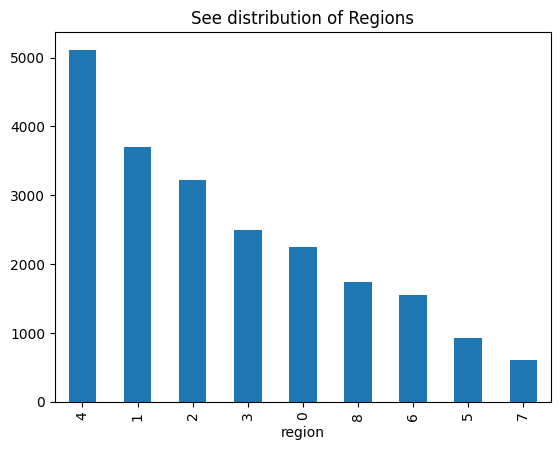

In [37]:
plt.title('See distribution of Regions')
df['region'].value_counts().plot(kind='bar')
plt.show()

In [38]:
region_stats = (
    df.groupby('region')['price']
      .agg(['count', 'mean', 'median'])
      .sort_values('mean')
)

region_stats

,count,mean,median
region,,,
6,1546,286746.595084,264500.0
2,3225,352702.448062,317500.0
5,924,360064.350649,329950.0
1,3703,423868.083446,365000.0
7,612,503012.666667,459970.0
3,2500,607756.764400,531000.0
4,5112,627239.276995,535000.0
0,2252,643452.221137,600000.0
8,1739,982841.371478,801501.0


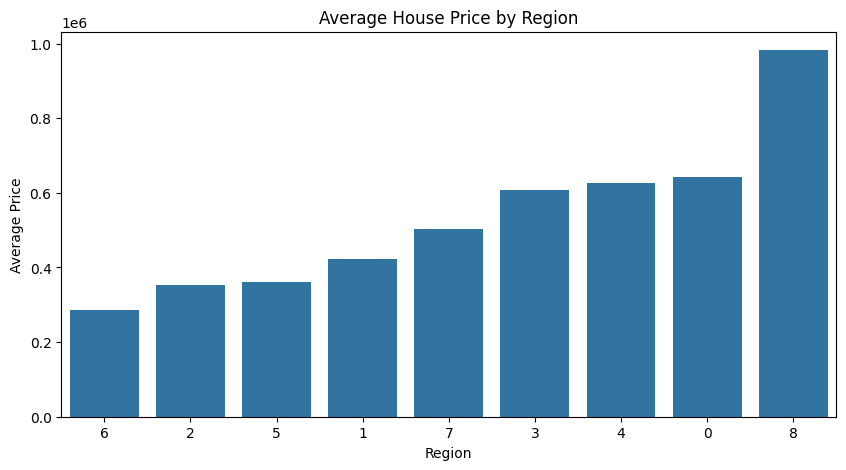

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

sns.barplot(
    x=region_stats.index.astype(str),
    y=region_stats['mean']
)

plt.xlabel("Region")
plt.ylabel("Average Price")
plt.title("Average House Price by Region")

plt.show()

In [40]:
df_grouped_region_water=df.groupby('region')['waterfront'].sum()
df_grouped_region_water

region
0    18
1    68
2     3
3    14
4    19
5     0
6    14
7     0
8    27
Name: waterfront, dtype: int64

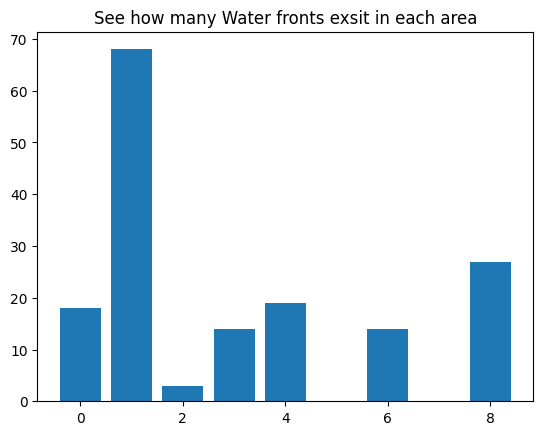

In [41]:
plt.title('See how many Water fronts exsit in each area')
plt.bar(x=df_grouped_region_water.index,height=df_grouped_region_water.values)
plt.show()

So, this confirm our thoughts, there is no relation between water front and thee price since region 8 not have the highest water fronts while it's the most expensive area

In [42]:
df.columns

Index(['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'yr_built', 'yr_renovated',
       'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15', 'sqft_lot',
       'sqft_above', 'sqft_basement', 'effective_year', 'age_when_sold',
       'lat_long', 'region'],
      dtype='object')

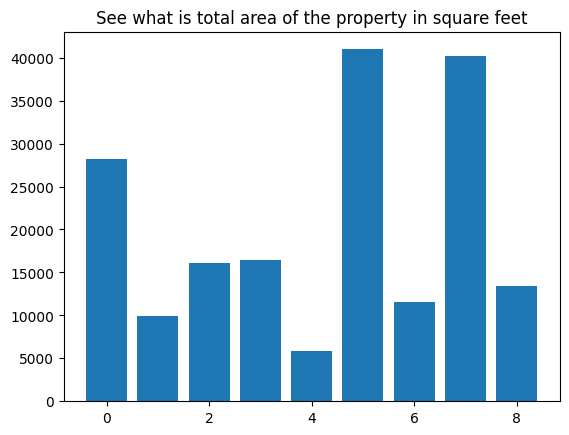

In [43]:
plt.title('See what is total area of the property in square feet')
df_grouped_region_sqftLot=df.groupby('region')['sqft_lot'].mean()
plt.bar(x=df_grouped_region_sqftLot.index,height=df_grouped_region_sqftLot.values)
plt.show()

In [44]:
def bars_depend_column(specific,col):
    
    temp=df.groupby(specific)[col].mean()
    plt.bar(x=temp.index,height=temp.values)
    plt.title(f'{col} depend on {specific}',fontsize=10)
    plt.ylabel('Count')
    

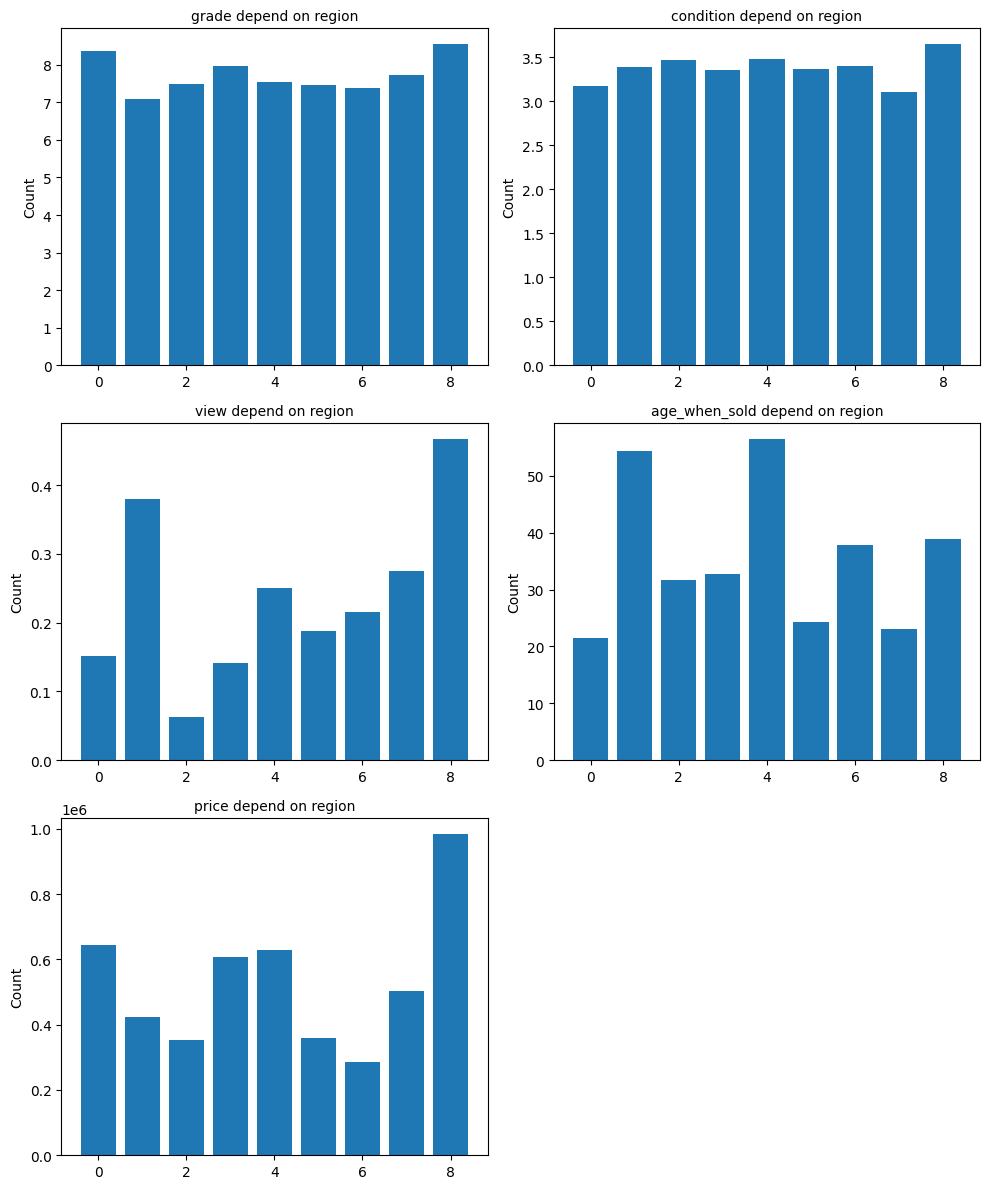

In [45]:
plt.figure(figsize=(10,12))
for ind,col in enumerate(start=1,iterable=['grade','condition','view','age_when_sold','price']):
    plt.subplot(3,2,ind)
    bars_depend_column('region',col)
    
plt.tight_layout()
plt.show()

### Check outliers

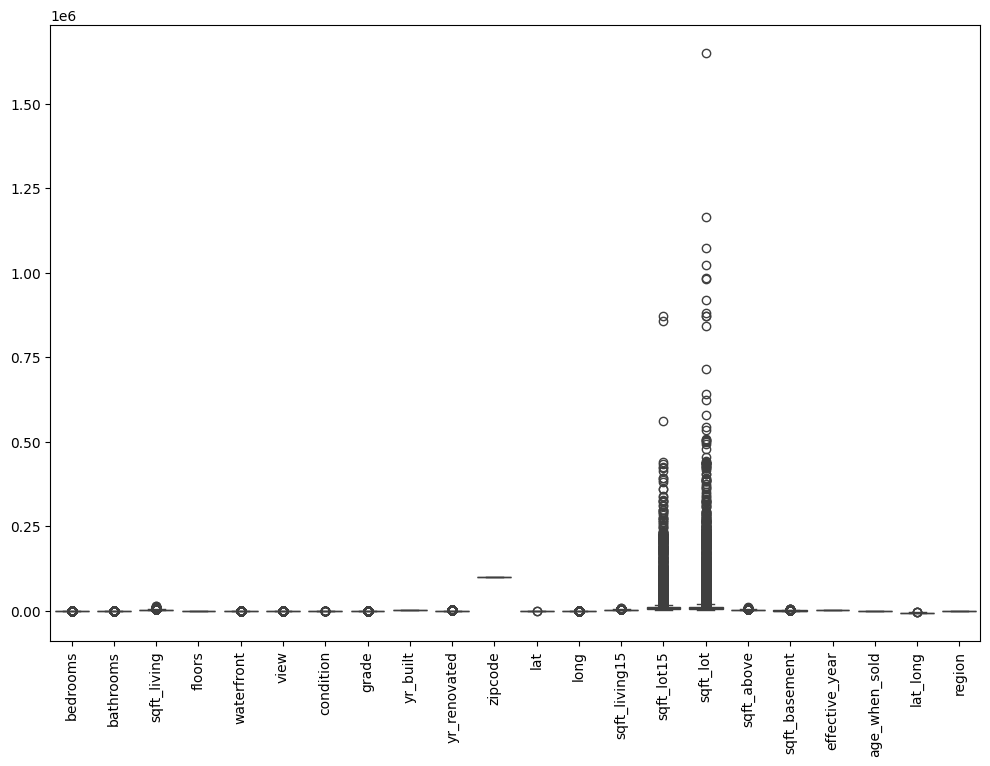

In [46]:
plt.figure(figsize=(12,8))
sns.boxplot(data=df.drop(columns=['id','price'],axis=1))
plt.xticks(rotation=90)
plt.show()

In [47]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
id,21613.0,4580301520.864988,1000102.0,2123049194.0,3904930410.0,7308900445.0,9900000190.0,2876565571.312049
date,21613,2014-10-29 04:38:01.959931648,2014-05-02 00:00:00,2014-07-22 00:00:00,2014-10-16 00:00:00,2015-02-17 00:00:00,2015-05-27 00:00:00,NaN
price,21613.0,540182.158793,75000.0,321950.0,450000.0,645000.0,7700000.0,367362.231718
bedrooms,21613.0,3.370842,0.0,3.0,3.0,4.0,33.0,0.930062
bathrooms,21613.0,2.114757,0.0,1.75,2.25,2.5,8.0,0.770163
sqft_living,21613.0,2079.899736,290.0,1427.0,1910.0,2550.0,13540.0,918.440897
floors,21613.0,1.494309,1.0,1.0,1.5,2.0,3.5,0.539989
waterfront,21613.0,0.007542,0.0,0.0,0.0,0.0,1.0,0.086517
view,21613.0,0.234303,0.0,0.0,0.0,0.0,4.0,0.766318
condition,21613.0,3.40943,1.0,3.0,3.0,4.0,5.0,0.650743


In [48]:
df[df['bedrooms']>4].describe().T

,count,mean,min,25%,50%,75%,max,std
id,1935.0,4492230517.119897,1000102.0,2011400020.0,4022900571.0,7213000440.0,9842300095.0,2832480048.008371
date,1935,2014-10-29 07:06:25.116278784,2014-05-02 00:00:00,2014-07-17 00:00:00,2014-10-19 00:00:00,2015-02-19 00:00:00,2015-05-15 00:00:00,NaN
price,1935.0,797892.839793,133000.0,439925.0,627000.0,911944.0,7700000.0,633503.960497
bedrooms,1935.0,5.237726,5.0,5.0,5.0,5.0,33.0,0.85767
bathrooms,1935.0,2.847287,1.0,2.25,2.75,3.25,8.0,0.908636
sqft_living,1935.0,3106.6,1120.0,2350.0,2890.0,3600.0,13540.0,1145.80561
floors,1935.0,1.588889,1.0,1.0,2.0,2.0,3.5,0.500884
waterfront,1935.0,0.011886,0.0,0.0,0.0,0.0,1.0,0.108402
view,1935.0,0.427907,0.0,0.0,0.0,0.0,4.0,1.016333
condition,1935.0,3.452196,1.0,3.0,3.0,4.0,5.0,0.665025


In [49]:
df[df['bedrooms']==33].head()

,id,date,price,bedrooms,bathrooms,sqft_living,floors,waterfront,view,condition,...,long,sqft_living15,sqft_lot15,sqft_lot,sqft_above,sqft_basement,effective_year,age_when_sold,lat_long,region
15870,2402100895,2014-06-25,640000.0,33,1.75,1620,1.0,0,0,5,...,-122.331,1330,4700,6000,1040,580,1947,67,-5833.696262,4


- Unrealitic as no way that bedrooms = 33 and bathrooms =1.75 !!
- also sqft_living is not enough for that all

bathrooms have floating-point numbers as this indicate if it's full bathrooms or there is bathrooms that is not totally stuff completed

In [50]:
df[df['sqft_lot']==1074218.0].head()

,id,date,price,bedrooms,bathrooms,sqft_living,floors,waterfront,view,condition,...,long,sqft_living15,sqft_lot15,sqft_lot,sqft_above,sqft_basement,effective_year,age_when_sold,lat_long,region
7647,2623069031,2014-05-21,542500.0,5,3.25,3010,1.5,0,0,5,...,-122.004,2450,68825,1074218,2010,1000,1931,83,-5789.870626,0


That is possible as it's may be farm or something

In [51]:
df[df['bathrooms']==8].head()

,id,date,price,bedrooms,bathrooms,sqft_living,floors,waterfront,view,condition,...,long,sqft_living15,sqft_lot15,sqft_lot,sqft_above,sqft_basement,effective_year,age_when_sold,lat_long,region
7252,6762700020,2014-10-13,7700000.0,6,8.0,12050,2.5,0,3,4,...,-122.323,3940,8800,27600,8570,3480,1987,27,-5826.220025,4
12777,1225069038,2014-05-05,2280000.0,7,8.0,13540,3.0,0,4,3,...,-121.986,4850,217800,307752,9410,4130,1999,15,-5814.767655,0


In [52]:
df[df['sqft_basement']==4820.0].head()

,id,date,price,bedrooms,bathrooms,sqft_living,floors,waterfront,view,condition,...,long,sqft_living15,sqft_lot15,sqft_lot,sqft_above,sqft_basement,effective_year,age_when_sold,lat_long,region
8092,1924059029,2014-06-17,4670000.0,5,6.75,9640,1.0,1,4,3,...,-122.21,3270,10454,13068,4820,4820,2009,5,-5811.94097,8


In [53]:
# ensure that sqft_living is good calc

df['sqft_living']=df['sqft_above']+df['sqft_basement']

### General Feature Engineering

In [54]:
df['ratio_sqftLiving_to_neig']=df['sqft_living']/df['sqft_living15']
df['ratio_sqftLot_to_neig']=df['sqft_lot']/df['sqft_lot15']
df['ratio_above_to_living']=df['sqft_above']/df['sqft_living']
df['ratio_base_to_living']=df['sqft_basement']/df['sqft_living']
df['total rate']=df['view']+df['condition']+df['grade']

In [55]:
df[(df['yr_renovated'] != 0) & (df['yr_renovated'] < df['yr_built'])]

,id,date,price,bedrooms,bathrooms,sqft_living,floors,waterfront,view,condition,...,sqft_basement,effective_year,age_when_sold,lat_long,region,ratio_sqftLiving_to_neig,ratio_sqftLot_to_neig,ratio_above_to_living,ratio_base_to_living,total rate


### Create features i can remove outliers with there help

In [56]:
df['basement_ratio'] = df['sqft_basement'] / df['sqft_living'].replace(0, np.nan)
df['above_ratio'] = df['sqft_above'] / df['sqft_living'].replace(0, np.nan)

df['sqft_liv_per_bedroom'] = df['sqft_living'] / df['bedrooms'].replace(0, np.nan)
df['ratio_bathrooms_to_bedrooms'] = df['bathrooms'] / df['bedrooms'].replace(0, np.nan)

In [57]:
df.columns

Index(['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'yr_built', 'yr_renovated',
       'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15', 'sqft_lot',
       'sqft_above', 'sqft_basement', 'effective_year', 'age_when_sold',
       'lat_long', 'region', 'ratio_sqftLiving_to_neig',
       'ratio_sqftLot_to_neig', 'ratio_above_to_living',
       'ratio_base_to_living', 'total rate', 'basement_ratio', 'above_ratio',
       'sqft_liv_per_bedroom', 'ratio_bathrooms_to_bedrooms'],
      dtype='object')

In [58]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
id,21613.0,4580301520.864988,1000102.0,2123049194.0,3904930410.0,7308900445.0,9900000190.0,2876565571.312049
date,21613,2014-10-29 04:38:01.959931648,2014-05-02 00:00:00,2014-07-22 00:00:00,2014-10-16 00:00:00,2015-02-17 00:00:00,2015-05-27 00:00:00,NaN
price,21613.0,540182.158793,75000.0,321950.0,450000.0,645000.0,7700000.0,367362.231718
bedrooms,21613.0,3.370842,0.0,3.0,3.0,4.0,33.0,0.930062
bathrooms,21613.0,2.114757,0.0,1.75,2.25,2.5,8.0,0.770163
sqft_living,21613.0,2079.899736,290.0,1427.0,1910.0,2550.0,13540.0,918.440897
floors,21613.0,1.494309,1.0,1.0,1.5,2.0,3.5,0.539989
waterfront,21613.0,0.007542,0.0,0.0,0.0,0.0,1.0,0.086517
view,21613.0,0.234303,0.0,0.0,0.0,0.0,4.0,0.766318
condition,21613.0,3.40943,1.0,3.0,3.0,4.0,5.0,0.650743


In [59]:
df[df['sqft_liv_per_bedroom']==3420.0]

,id,date,price,bedrooms,bathrooms,sqft_living,floors,waterfront,view,condition,...,region,ratio_sqftLiving_to_neig,ratio_sqftLot_to_neig,ratio_above_to_living,ratio_base_to_living,total rate,basement_ratio,above_ratio,sqft_liv_per_bedroom,ratio_bathrooms_to_bedrooms
2444,7524900003,2014-12-10,3280000.0,2,1.75,6840,2.5,1,4,3,...,8,2.192308,0.813008,0.635965,0.364035,18,0.364035,0.635965,3420.0,0.875


In [60]:
df_backup=df.copy()

In [61]:
upper = df['sqft_liv_per_bedroom'].quantile(0.99)
upper

1317.5

In [62]:
df = df[df['sqft_liv_per_bedroom'] <= upper]

In [63]:
upper = df['ratio_bathrooms_to_bedrooms'].quantile(0.99)
upper

1.25

In [64]:
df = df[df['ratio_bathrooms_to_bedrooms'] <= upper]

In [65]:
df.shape

(21317, 34)

In [66]:
df_backup.shape

(21613, 34)

In [67]:
df.columns

Index(['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'yr_built', 'yr_renovated',
       'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15', 'sqft_lot',
       'sqft_above', 'sqft_basement', 'effective_year', 'age_when_sold',
       'lat_long', 'region', 'ratio_sqftLiving_to_neig',
       'ratio_sqftLot_to_neig', 'ratio_above_to_living',
       'ratio_base_to_living', 'total rate', 'basement_ratio', 'above_ratio',
       'sqft_liv_per_bedroom', 'ratio_bathrooms_to_bedrooms'],
      dtype='object')

### Feature Selection

In [68]:
import numpy as np
import pandas as pd
from scipy.stats import f_oneway

# -----------------------------
# Define feature types
# -----------------------------
target = "price"

ordinal_features = [
    "condition",
    "grade",
    "view",
    "floors",
    'waterfront',
    'total rate'
]

nominal_features = [
    "zipcode",
    "region"
]

# Numeric columns
numeric_features = df.select_dtypes(include=np.number).columns.tolist()

# Remove target
numeric_features.remove(target)

# Remove ordinal & nominal from numeric list
numeric_features = [
    col for col in numeric_features
    if col not in ordinal_features + nominal_features
]

In [69]:
numeric_features

['id',
 'bedrooms',
 'bathrooms',
 'sqft_living',
 'yr_built',
 'yr_renovated',
 'lat',
 'long',
 'sqft_living15',
 'sqft_lot15',
 'sqft_lot',
 'sqft_above',
 'sqft_basement',
 'effective_year',
 'age_when_sold',
 'lat_long',
 'ratio_sqftLiving_to_neig',
 'ratio_sqftLot_to_neig',
 'ratio_above_to_living',
 'ratio_base_to_living',
 'basement_ratio',
 'above_ratio',
 'sqft_liv_per_bedroom',
 'ratio_bathrooms_to_bedrooms']

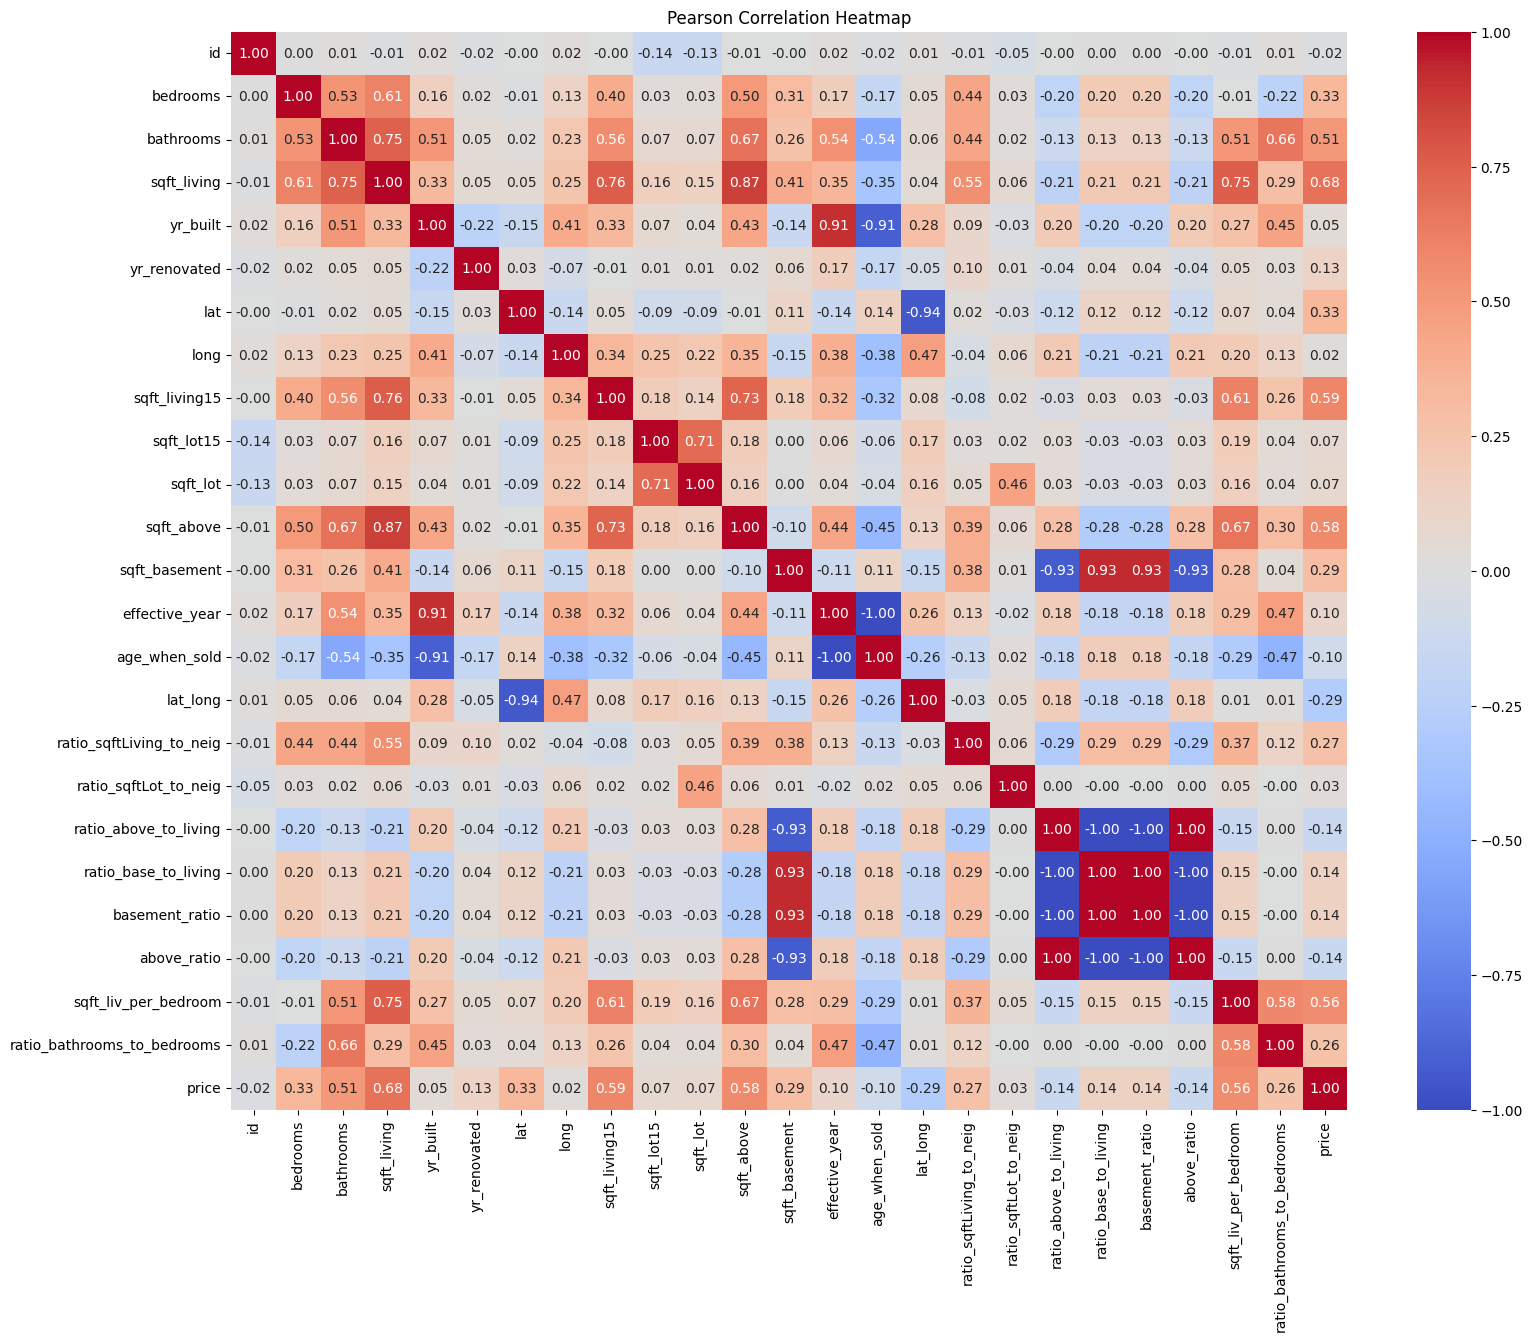

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = df[numeric_features + [target]].corr(method="pearson")

plt.figure(figsize=(18,14))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f",
    vmin=-1,vmax=1
)

plt.title("Pearson Correlation Heatmap")
plt.show()

In [71]:
df.columns

Index(['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'yr_built', 'yr_renovated',
       'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15', 'sqft_lot',
       'sqft_above', 'sqft_basement', 'effective_year', 'age_when_sold',
       'lat_long', 'region', 'ratio_sqftLiving_to_neig',
       'ratio_sqftLot_to_neig', 'ratio_above_to_living',
       'ratio_base_to_living', 'total rate', 'basement_ratio', 'above_ratio',
       'sqft_liv_per_bedroom', 'ratio_bathrooms_to_bedrooms'],
      dtype='object')

In [72]:
needed_numeric_features=['sqft_living','sqft_living15','sqft_liv_per_bedroom','bathrooms', 'bedrooms', 'lat']

In [73]:
kendall_results = {}

for col in ordinal_features:
    kendall_results[col] = df[col].corr(df[target], method="kendall")

kendall_results = (
    pd.Series(kendall_results)
    .sort_values(key=abs, ascending=False)
)

print(kendall_results)

grade         0.520780
total rate    0.495177
floors        0.248362
view          0.226228
waterfront    0.084331
condition     0.016655
dtype: float64


In [74]:
needed_ordinal_features=['grade']

In [75]:
anova_results = {}

for col in nominal_features:

    groups = [
        group[target].values
        for _, group in df.groupby(col)
    ]

    F, p = f_oneway(*groups)

    anova_results[col] = {
        "F-statistic": F,
        "p-value": p
    }

anova_results = (
    pd.DataFrame(anova_results)
    .T
    .sort_values("F-statistic", ascending=False)
)

print(anova_results)

         F-statistic  p-value
region    977.597361      0.0
zipcode   246.863950      0.0


In [76]:
needed_nominal_features=['region']

In [77]:
all_features=needed_nominal_features+needed_numeric_features+needed_ordinal_features
all_features

['region',
 'sqft_living',
 'sqft_living15',
 'sqft_liv_per_bedroom',
 'bathrooms',
 'bedrooms',
 'lat',
 'grade']

In [78]:
df_selected=df[all_features+['price']]

In [79]:
df_selected.head()

,region,sqft_living,sqft_living15,sqft_liv_per_bedroom,bathrooms,bedrooms,lat,grade,price
0,1,1180,1340,393.333333,1.00,3,47.5112,7,221900.0
1,4,2570,1690,856.666667,2.25,3,47.7210,7,538000.0
2,3,770,2720,385.000000,1.00,2,47.7379,6,180000.0
3,1,1960,1360,490.000000,3.00,4,47.5208,7,604000.0
4,0,1680,1800,560.000000,2.00,3,47.6168,8,510000.0


In [80]:
upper = df_selected['price'].quantile(0.99)
upper

1850000.0

In [81]:

df_selected = df_selected[df_selected['price'] <= upper]

In [82]:
from sklearn.model_selection import train_test_split

df_train,df_test=train_test_split(df_selected,train_size=0.8,shuffle=True,random_state=42)

In [83]:
df_train

,region,sqft_living,sqft_living15,sqft_liv_per_bedroom,bathrooms,bedrooms,lat,grade,price
200,2,860,1300,286.666667,1.00,3,47.5093,6,210000.0
1153,2,1830,1860,610.000000,2.50,3,47.3291,8,298900.0
14272,2,2600,2350,866.666667,2.50,3,47.5123,8,475000.0
11879,1,1730,1780,576.666667,2.50,3,47.4320,7,339950.0
7729,1,1250,1270,625.000000,2.00,2,47.5426,7,340000.0
...,...,...,...,...,...,...,...,...,...
11541,8,2020,2370,673.333333,1.75,3,47.5740,8,677500.0
12232,4,1060,1820,530.000000,1.00,2,47.6896,6,344000.0
5529,4,1420,1420,473.333333,2.50,3,47.7027,7,435000.0
886,4,2400,2100,480.000000,3.25,5,47.6094,7,700000.0


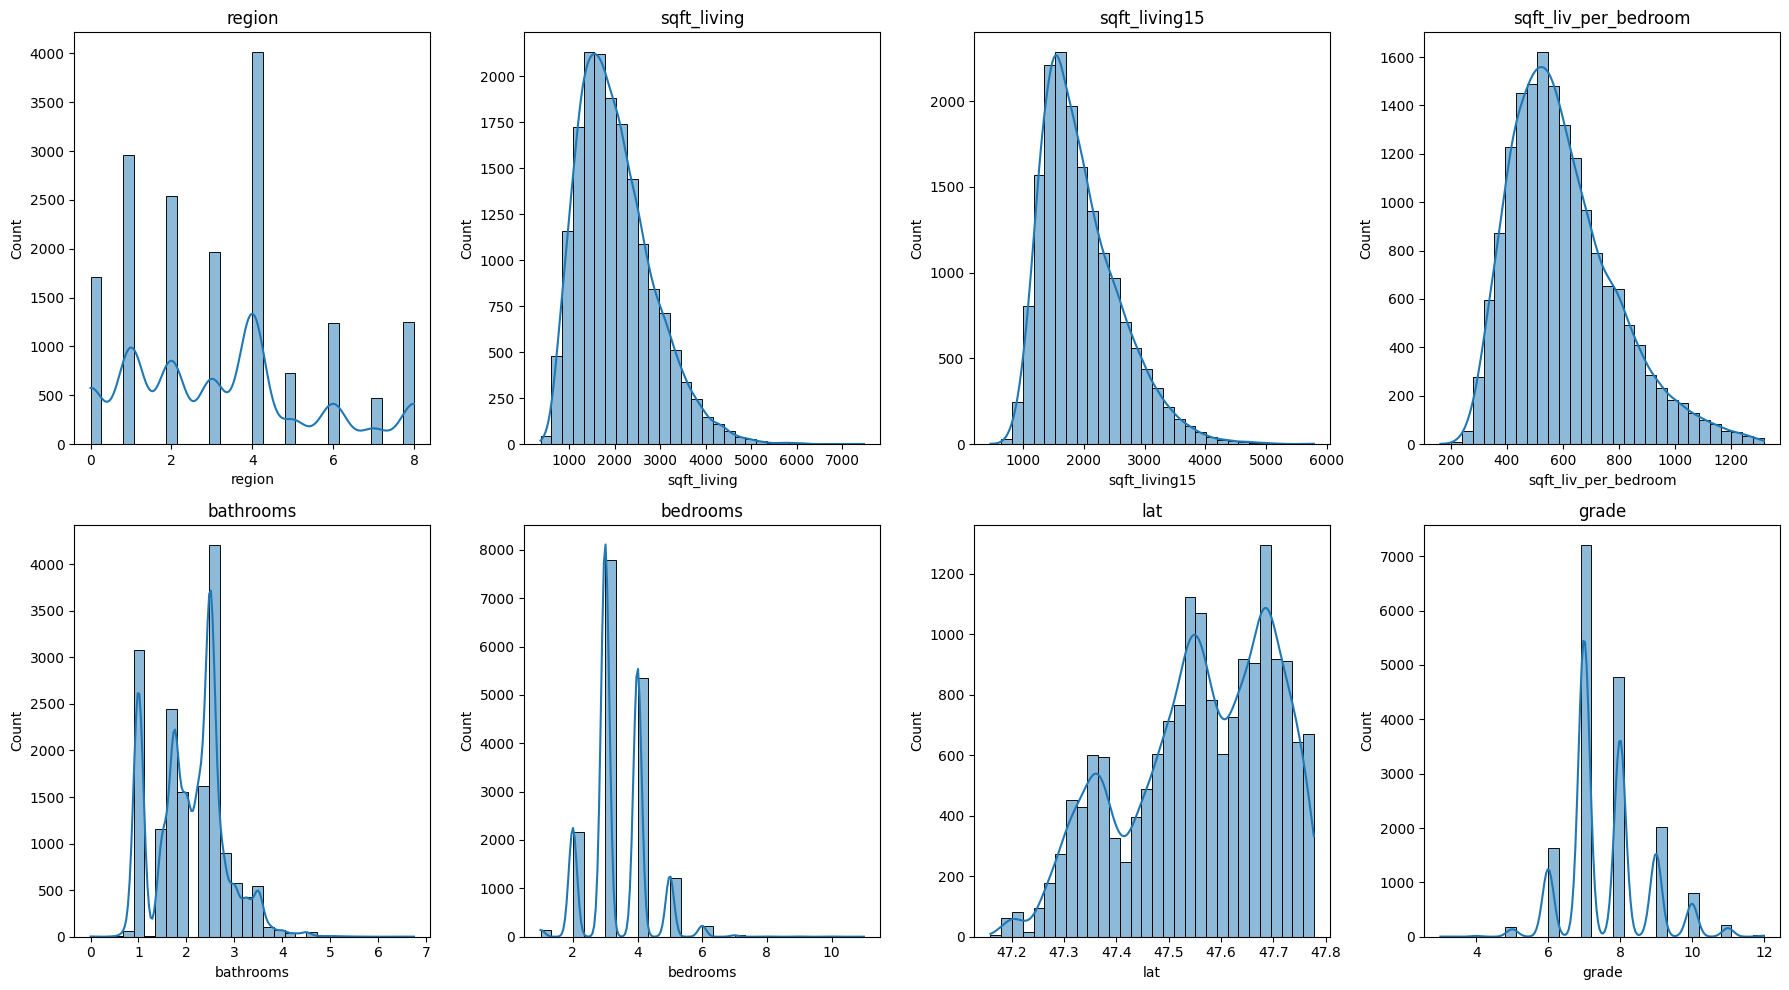

In [87]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

cols = list(df_train.drop('price',axis=1).columns)

plots_per_fig = 8
n_cols = 4
n_rows = 2

for start in range(0, len(cols), plots_per_fig):

    current_cols = cols[start:start + plots_per_fig]

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 10))
    axes = axes.flatten()

    for ax, col in zip(axes, current_cols):
        sns.histplot(
            x=df_train[col],
            bins=30,
            kde=True,
            ax=ax
        )

        ax.set_title(col)
        ax.set_xlabel(col)
        ax.set_ylabel("Count")

    # Remove unused axes in the last figure
    for ax in axes[len(current_cols):]:
        fig.delaxes(ax)

    plt.tight_layout()
    plt.show()

In [85]:
df_train.to_csv(r'data/df_train_org.csv',index=False)
df_test.to_csv(r'data/df_test_org.csv',index=False)

In [88]:
df_selected.describe().T

,count,mean,std,min,25%,50%,75%,max
region,21105.0,3.220943,2.260943,0.000000,1.000000,3.0000,4.0000,8.000000e+00
sqft_living,21105.0,2029.242502,825.242709,370.000000,1420.000000,1890.0000,2500.0000,7.480000e+03
sqft_living15,21105.0,1960.332149,654.149927,399.000000,1480.000000,1820.0000,2330.0000,5.790000e+03
sqft_liv_per_bedroom,21105.0,603.737548,188.948622,49.090909,466.666667,570.0000,710.0000,1.317500e+03
bathrooms,21105.0,2.085359,0.733897,0.000000,1.500000,2.2500,2.5000,7.500000e+00
bedrooms,21105.0,3.368728,0.915097,1.000000,3.000000,3.0000,4.0000,3.300000e+01
lat,21105.0,47.559100,0.139323,47.155900,47.467800,47.5703,47.6786,4.777760e+01
grade,21105.0,7.604170,1.109338,3.000000,7.000000,7.0000,8.0000,1.300000e+01
price,21105.0,510247.692016,270280.548361,75000.000000,320000.000000,446500.0000,628000.0000,1.850000e+06


### See after onehot encoding for region

In [89]:
df_train_enc=pd.read_csv(r'data/df_train_encoded.csv')
df_train_enc.head()

,sqft_living,sqft_living15,sqft_liv_per_bedroom,bathrooms,bedrooms,lat,grade,price,region_0,region_1,region_2,region_3,region_4,region_5,region_6,region_7,region_8
0,860,1300,286.666667,1.0,3,47.5093,6,210000.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1830,1860,610.000000,2.5,3,47.3291,8,298900.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2600,2350,866.666667,2.5,3,47.5123,8,475000.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1730,1780,576.666667,2.5,3,47.4320,7,339950.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1250,1270,625.000000,2.0,2,47.5426,7,340000.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### See after power trans

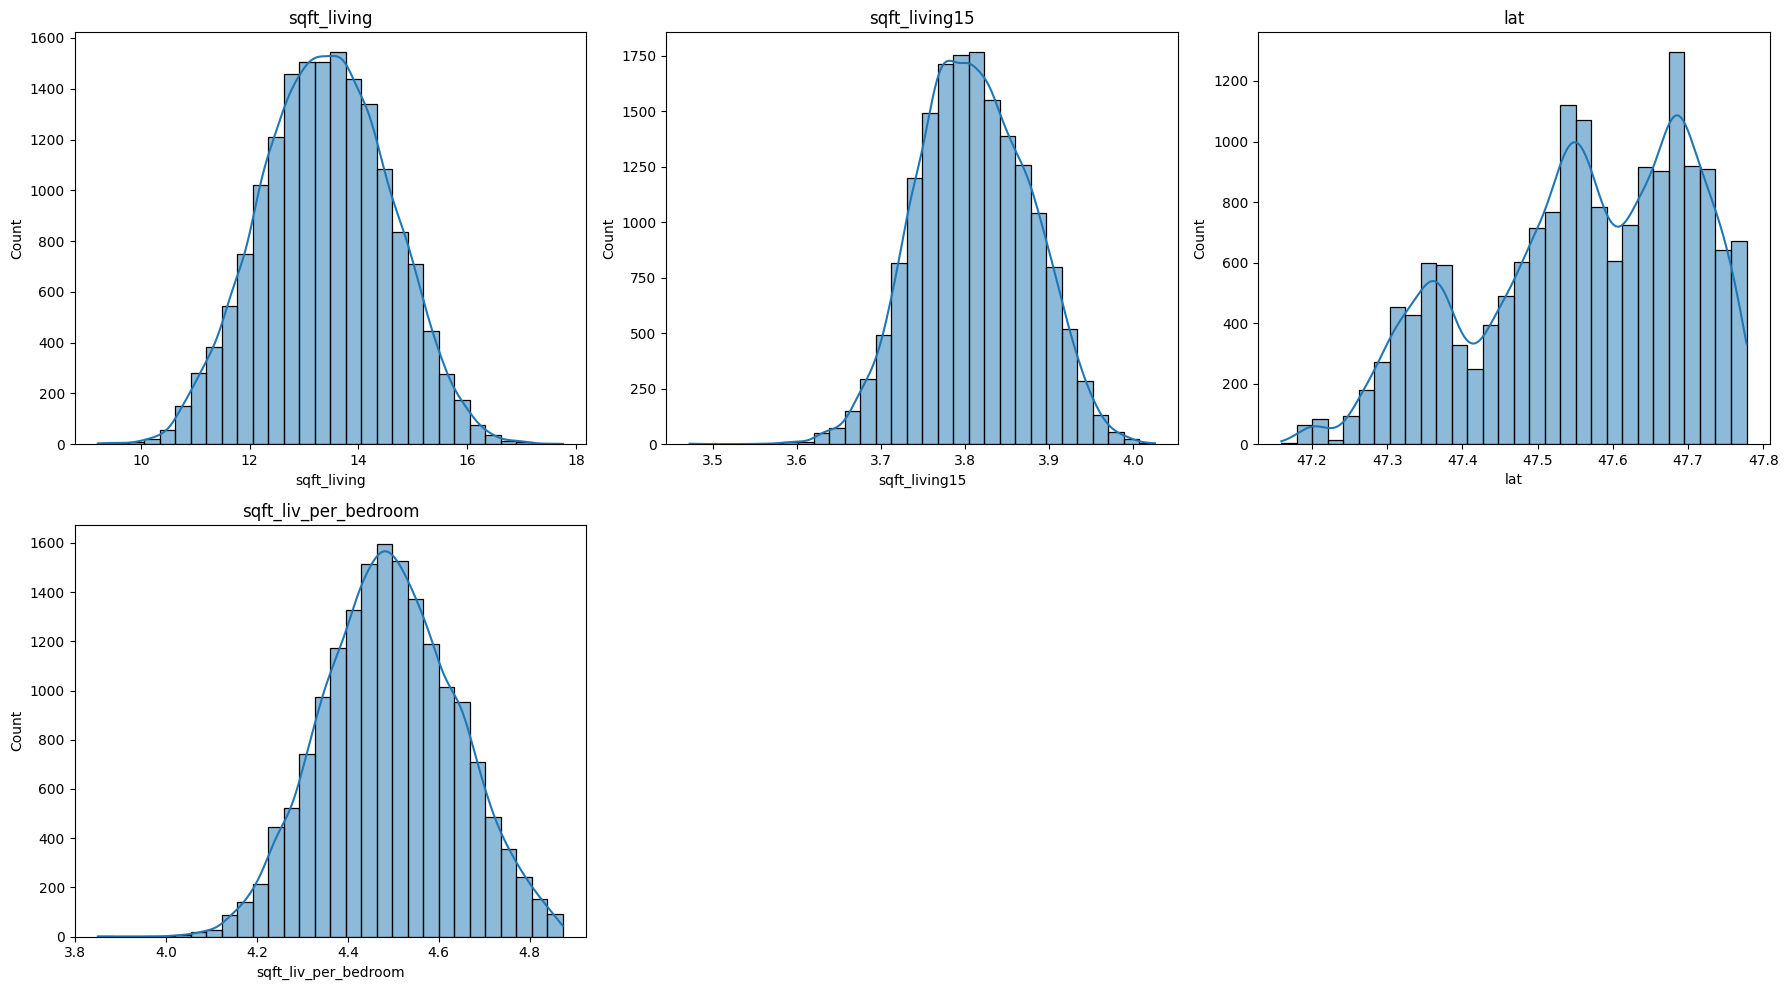

In [92]:
df_train_trans=pd.read_csv(r'data/df_train_trans.csv')

import matplotlib.pyplot as plt
import seaborn as sns
import math

cols = ['sqft_living','sqft_living15','lat','sqft_liv_per_bedroom']

plots_per_fig = 6
n_cols = 3
n_rows = 2

for start in range(0, len(cols), plots_per_fig):

    current_cols = cols[start:start + plots_per_fig]

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 10))
    axes = axes.flatten()

    for ax, col in zip(axes, current_cols):
        sns.histplot(
            x=df_train_trans[col],
            bins=30,
            kde=True,
            ax=ax
        )

        ax.set_title(col)
        ax.set_xlabel(col)
        ax.set_ylabel("Count")

    # Remove unused axes in the last figure
    for ax in axes[len(current_cols):]:
        fig.delaxes(ax)

    plt.tight_layout()
    plt.show()